# Full OFF cell Trial Model

The models in this notebook will fit to the entirety of the trial activity of the OFF cells (pre and post) simultaneously.

In [1]:
# Autoreloading of modules and files without restarting notebook.
%reload_ext autoreload
%autoreload 2

import os
import json
import arviz as az
import numpy as np
from pathlib import Path
from quantities import s
import matplotlib.pyplot as plt
from pymc import model_to_graphviz


from rvm_analysis.utils import combine_datasets_into_data_manager
from rvm_analysis.utils import import_on_off_trials, import_extra_cells
from rvm_analysis.trial_analysis_functions import create_trial_df
from rvm_analysis.bayesian_cell_models import build_linear_slope_recovery_off_model, store_model_predictions
from rvm_analysis.bayesian_cell_models import plot_prior_predictive_checks,calculate_rate_percentages_of_peak_OFF
from rvm_analysis.bayesian_cell_models import create_X_and_Y_training_data
from rvm_analysis.bayesian_cell_models import sample_model,compute_and_save_log_likelihood,compute_predictions_over_new_data
from rvm_analysis.plotting import plot_predictions_paper
from rvm_analysis.data_loaders import read_dataset_by_protocol


#! Force the backend back to matplotlib inline (after importing viziphant).
%matplotlib inline
print(plt.get_backend())

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

module://matplotlib_inline.backend_inline


## Import the trial data

In [2]:
def deprecated_spike_2_imports():
    """
    Data imports, deprecated in favour of importing directly from NWB.
    """
    dm1 = import_on_off_trials()
    dm2 = import_extra_cells()
    dm = combine_datasets_into_data_manager(dm1,dm2)
    return dm


dm = read_dataset_by_protocol(['evoked','ongoing','evoked/ongoing'])

Found 101 blocks from 101 NWB files.
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Mus03_CA3.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Mus23_CA2.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Mus25_CA2.smrx
['EKG', 'paw_withdrawal', 'heat', 'pinch']
['EKG', 'flick', 'heat', 'keyboard']
LHb_Mus28_CA2.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Bic04_CA3.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Bic05_CA3.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Bic07_CA3.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Bic16_CA2.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Bic20_CA3.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Bic27_CA2.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Bic36_CA2.smrx
['EKG', 'paw_withdrawal', 'heat']
['EKG', 'flick', 'heat']
LHb_Mus06_CA2.smrx
['EKG'

In [3]:
base_path: Path = Path("./models/off_models/21_OFF_cells_linear_slope_aggregated")
model_name ="off_trial_model.nc"
full_path = base_path / model_name
parameter_dictionary = base_path / "param_dict.json"

with open(parameter_dictionary,"r") as f:
    p: dict = json.load(f)

p

{'POST_EVENT_PERIOD': 100,
 'PRE_EVENT_PERIOD': -10,
 'SKIP': 1,
 'DRAWS': 1000,
 'TUNE': 1000,
 'BIN_SIZE': 0.05,
 'PRIORS': {'SIGMA_B': 4,
  'SIGMA_A': 4,
  'T_LOWER': -4,
  'T_UPPER': 4,
  'K': 1,
  'K2': 1,
  'K3': 1}}

In [4]:
off_flick_list, off_flick_list_by_cell = dm.plot_spikes_around_event("flick",p["PRE_EVENT_PERIOD"] * s,p["POST_EVENT_PERIOD"] * s,
                                                                             cell_type='OFF',sorted_by=None,color_by_file=False,
                                                                             save=None,plot=False)

print(len(off_flick_list))

Next event [end,960.6372463999999 s] cuts off window
Next event [end,960.6372463999999 s] cuts off window
Next event [end,960.6323349999999 s] cuts off window
Next event [end,965.3120307999999 s] cuts off window
Next event [end,965.3120307999999 s] cuts off window
Next event [end,967.7341075999999 s] cuts off window
Next event [end,967.7341075999999 s] cuts off window
Next event [end,961.8416963999999 s] cuts off window
Next event [end,960.6701883999999 s] cuts off window
Next event [end,960.8069171999999 s] cuts off window
Next event [end,961.6389431999999 s] cuts off window
Next event [end,961.6389431999999 s] cuts off window
Next event [end,962.4861661999998 s] cuts off window
Next event [end,962.4861661999998 s] cuts off window
Next event [end,961.2888323999999 s] cuts off window
Next event [end,961.2888323999999 s] cuts off window
Next event [heat,306.67527279999996 s] cuts off window
Next event [end,963.6889001999999 s] cuts off window
Next event [end,963.6889001999999 s] cuts of

,index,animal,cell,trial,time,count
0,0,LHb_Mus03_CA3.smrx,0,0,-10.00,0
1,1,LHb_Mus03_CA3.smrx,0,0,-9.95,0
2,2,LHb_Mus03_CA3.smrx,0,0,-9.90,0
3,3,LHb_Mus03_CA3.smrx,0,0,-9.85,0
4,4,LHb_Mus03_CA3.smrx,0,0,-9.80,0
...,...,...,...,...,...,...
373995,373995,LHb_Mus22_CA2.smrx,59,2,99.75,0
373996,373996,LHb_Mus22_CA2.smrx,59,2,99.80,0
373997,373997,LHb_Mus22_CA2.smrx,59,2,99.85,0
373998,373998,LHb_Mus22_CA2.smrx,59,2,99.90,0


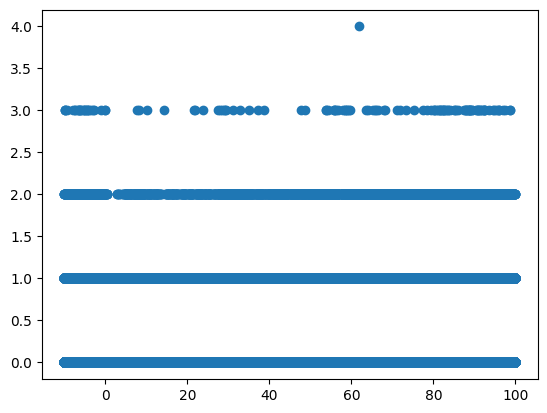

       time  count
0    -10.00     45
1     -9.95     57
2     -9.90     38
3     -9.85     50
4     -9.80     43
...     ...    ...
2195  99.75     35
2196  99.80     34
2197  99.85     28
2198  99.90     38
2199  99.95     34

[2200 rows x 2 columns]


In [5]:
df = create_trial_df(p["BIN_SIZE"] * s,off_flick_list_by_cell)
display(df)

# Plot the raw count data
plt.scatter(df['time'],df['count'])
plt.show()

counts = df.groupby('time',as_index=False)['count'].sum()
print(counts)

## Define Our Model

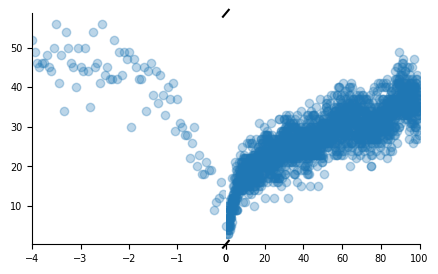

In [6]:
X_data,Y_data = create_X_and_Y_training_data(counts,skip=1,plot=True)

In [7]:
off_model = build_linear_slope_recovery_off_model(X_data,Y_data,p)

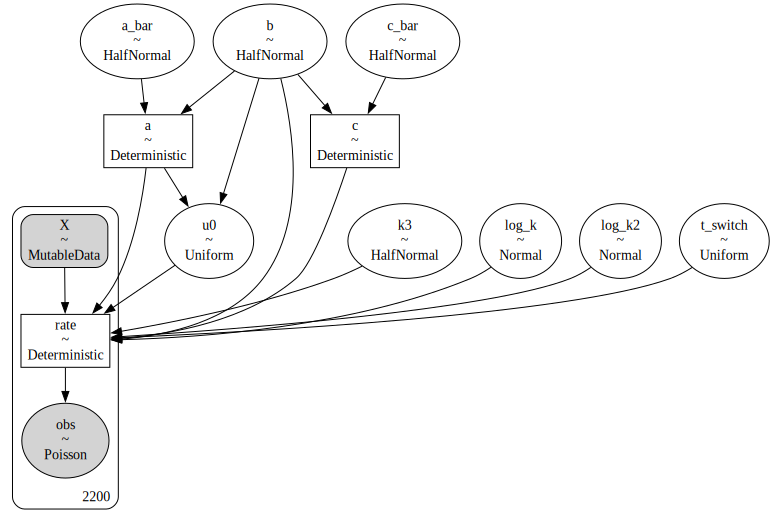

In [8]:
model_to_graphviz(off_model,save=os.path.join(base_path,"graph.png")) # .render('model')

Sampling: [a_bar, b, c_bar, k3, log_k, log_k2, t_switch, u0]
[distfit] >INFO> Sampling: [a_bar, b, c_bar, k3, log_k, log_k2, t_switch, u0]


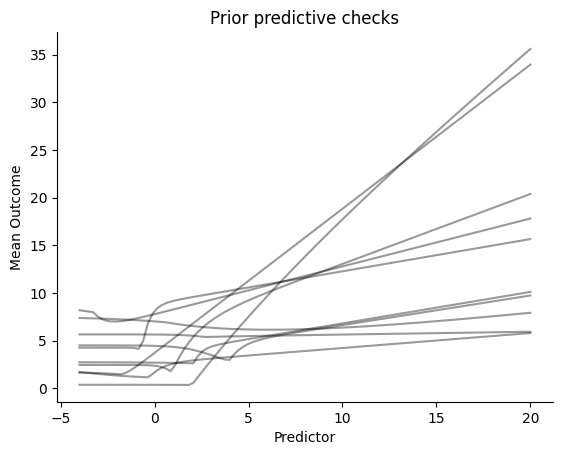

In [9]:
X_test = np.linspace(-4,20,100)
plot_prior_predictive_checks(off_model,X_test,n_sample_paths=10)

## Sample from the model

In [10]:
SAMPLE = False
idata = sample_model(off_model,X_data,full_path,p,sample=SAMPLE,chains=4)


# Calculate tau values and exponentiated HDIs
posterior = idata.posterior
derived_params = {
"k": np.exp(posterior['log_k']),
"k2": np.exp(posterior['log_k2']),
"tau_post": 1/np.exp(posterior['log_k2']),
}

idata.posterior = idata.posterior.assign(**derived_params)

## Compute the model log likelihood and save

In [11]:
COMPUTE_LL = False
loglik_save_path = base_path / "idata_with_log_liks.nc" 

compute_and_save_log_likelihood(off_model,idata,save_path=loglik_save_path,recompute=COMPUTE_LL)

## Summarize the model

In [12]:
var_names=['a','b','c','k','k2',"tau_post","k3","t_switch","u0"]

In [13]:
# Print a summary of the model parameters
summary = az.summary(idata,var_names=var_names)

display(summary)

summary.to_latex(os.path.join(base_path,"posterior_table_OFF_flick_linear_exp.tex"),index=True, escape=True,
                 float_format="%.3f")


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,46.500,0.544,45.472,47.501,0.008,0.006,4484.0,2959.0,1.0
b,5.683,0.581,4.582,6.740,0.016,0.012,1272.0,1746.0,1.0
c,18.803,0.349,18.125,19.439,0.008,0.005,2143.0,2392.0,1.0
k,2.852,0.282,2.333,3.392,0.006,0.005,1863.0,2404.0,1.0
k2,0.213,0.026,0.163,0.260,0.001,0.000,1960.0,2223.0,1.0
tau_post,4.760,0.577,3.711,5.861,0.013,0.009,1960.0,2223.0,1.0
k3,0.186,0.006,0.174,0.196,0.000,0.000,1928.0,1902.0,1.0
t_switch,1.346,0.249,0.904,1.832,0.007,0.005,1313.0,1658.0,1.0
u0,5.839,0.496,4.947,6.781,0.013,0.009,1478.0,1928.0,1.0


array([[<Axes: title={'center': 'a'}>, <Axes: title={'center': 'a'}>],
       [<Axes: title={'center': 'b'}>, <Axes: title={'center': 'b'}>],
       [<Axes: title={'center': 'c'}>, <Axes: title={'center': 'c'}>],
       [<Axes: title={'center': 'k'}>, <Axes: title={'center': 'k'}>],
       [<Axes: title={'center': 'k2'}>, <Axes: title={'center': 'k2'}>],
       [<Axes: title={'center': 'tau_post'}>,
        <Axes: title={'center': 'tau_post'}>],
       [<Axes: title={'center': 'k3'}>, <Axes: title={'center': 'k3'}>],
       [<Axes: title={'center': 't_switch'}>,
        <Axes: title={'center': 't_switch'}>],
       [<Axes: title={'center': 'u0'}>, <Axes: title={'center': 'u0'}>]],
      dtype=object)

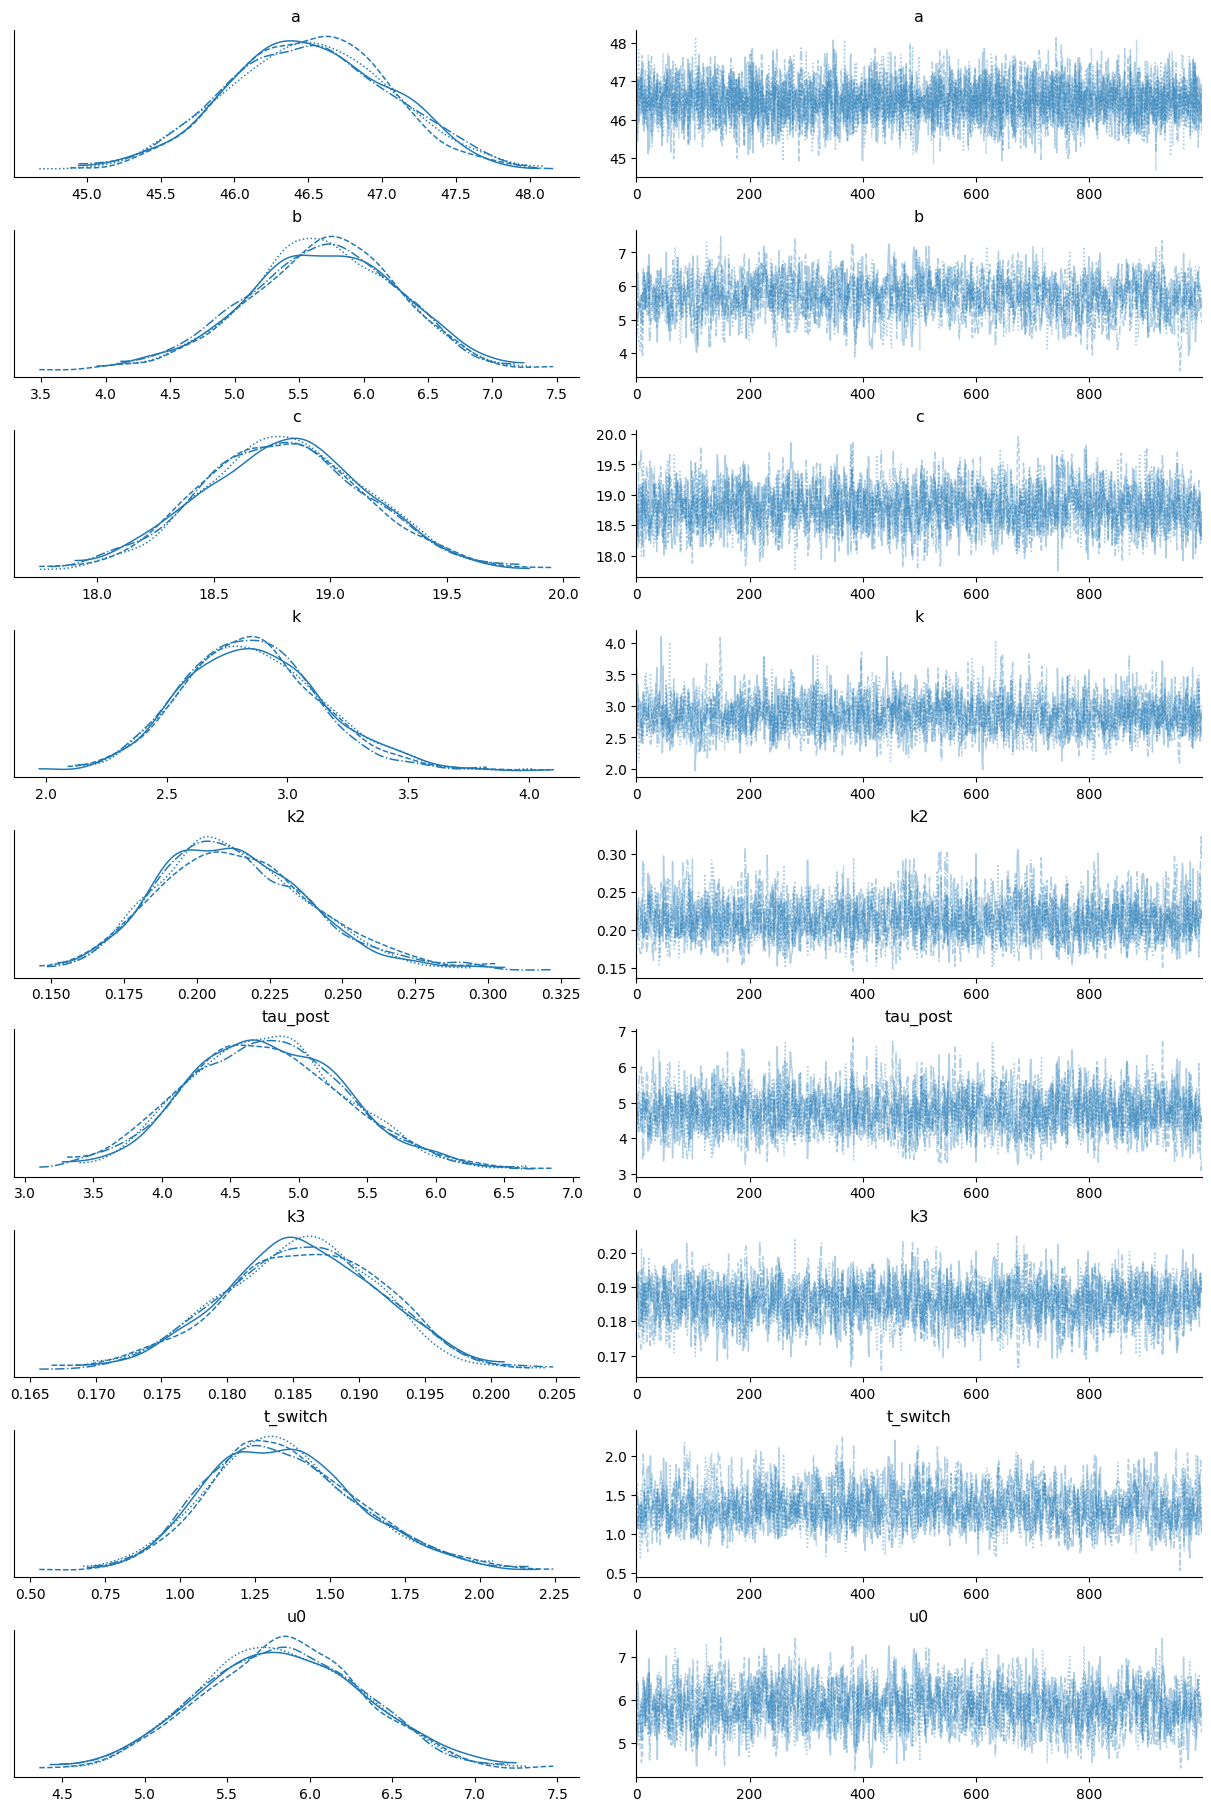

In [14]:
# plot the traces of the model
az.plot_trace(idata,backend_kwargs={'layout': 'constrained'},
              var_names=var_names
              )

## Compute predictions over a set of new input points

In [15]:
X_test = np.linspace(-10,100,2000)
idata_predictions = compute_predictions_over_new_data(off_model,idata,X_test)

Sampling: [count_pred_new]
[distfit] >INFO> Sampling: [count_pred_new]


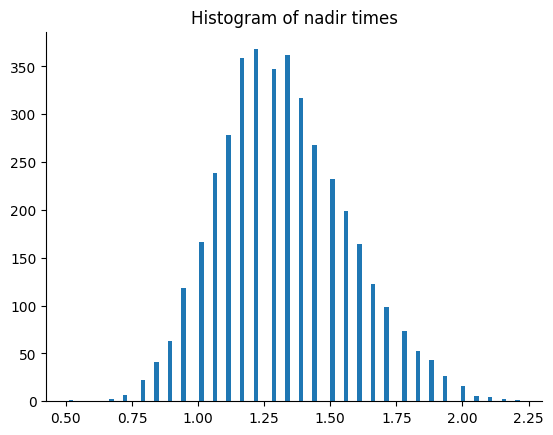

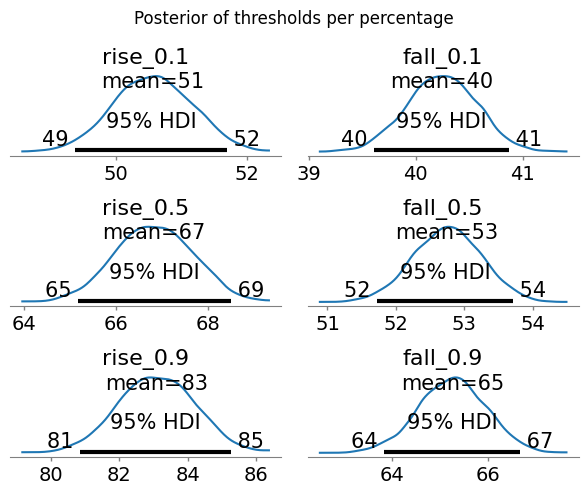

Summary (mean, median, 97.0% HDI):

                         mean     sd  hdi_1.5%  hdi_98.5%  mcse_mean  mcse_sd  \
Time to fall by 10.0%  -1.502  0.102    -1.746     -1.306      0.002    0.001   
Time to rise to 10.0%  83.171  0.478    82.116     84.097      0.013    0.009   

                       ess_bulk  ess_tail  r_hat  
Time to fall by 10.0%    2400.0    2654.0    1.0  
Time to rise to 10.0%    1454.0    1787.0    1.0  

Explicit numeric results:
Rise to 0.1% - mean: 83.171, median: 83.217, 97.0% HDI: [82.116, 84.097]
Fall to 0.1% - mean: -1.502, median: -1.471, 97.0% HDI: [-1.746, -1.306]
Summary (mean, median, 97.0% HDI):

                         mean     sd  hdi_1.5%  hdi_98.5%  mcse_mean  mcse_sd  \
Time to fall by 50.0%  -0.725  0.048    -0.810     -0.645      0.001    0.001   
Time to rise to 50.0%  18.069  1.394    15.148     21.036      0.033    0.024   

                       ess_bulk  ess_tail  r_hat  
Time to fall by 50.0%    3794.0    3585.0    1.0  
Time to rise

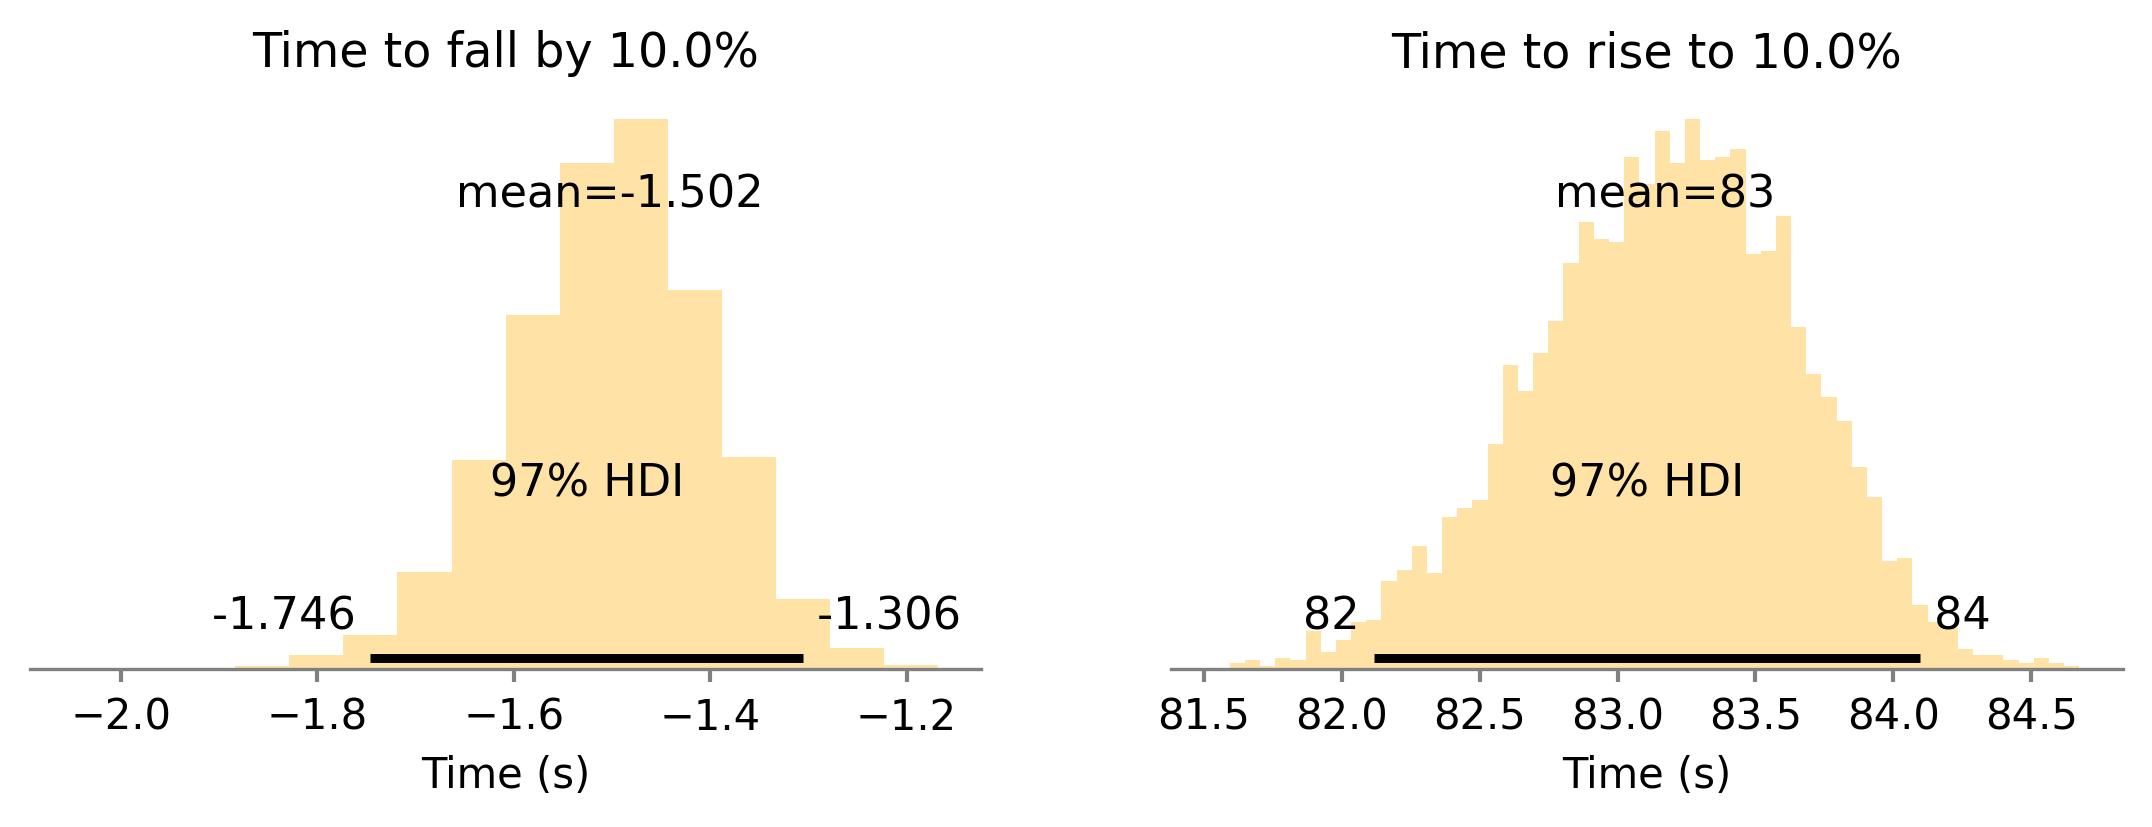

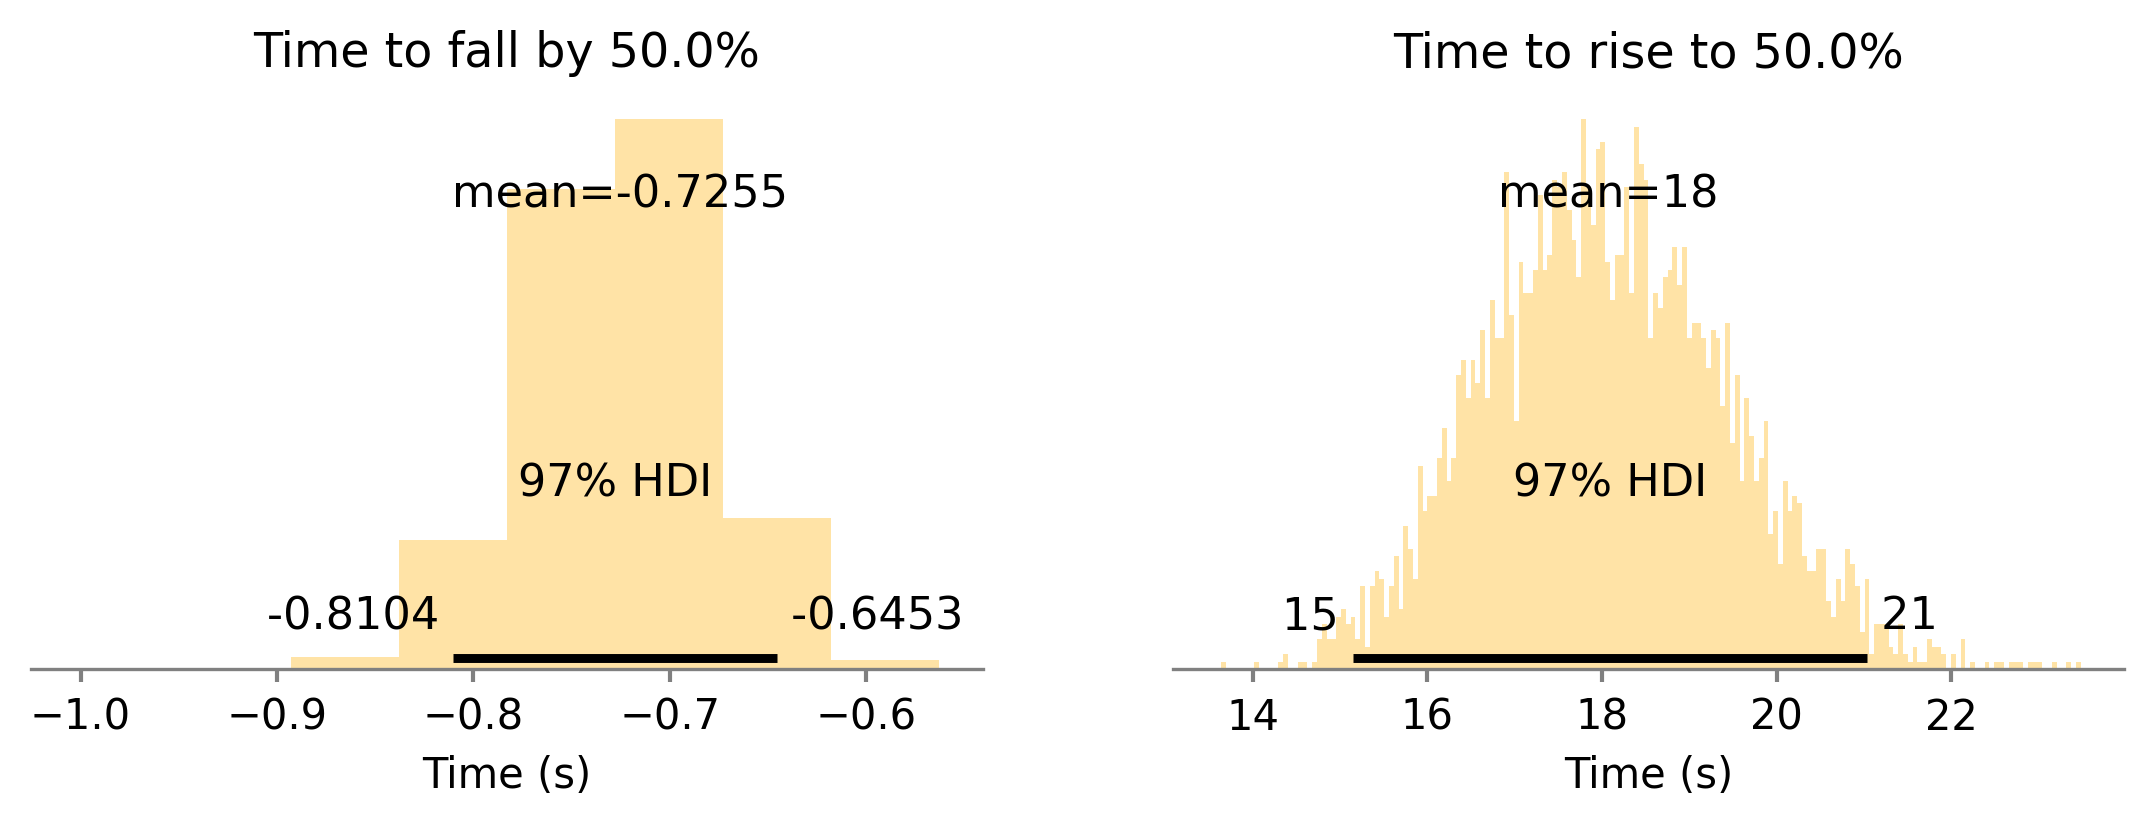

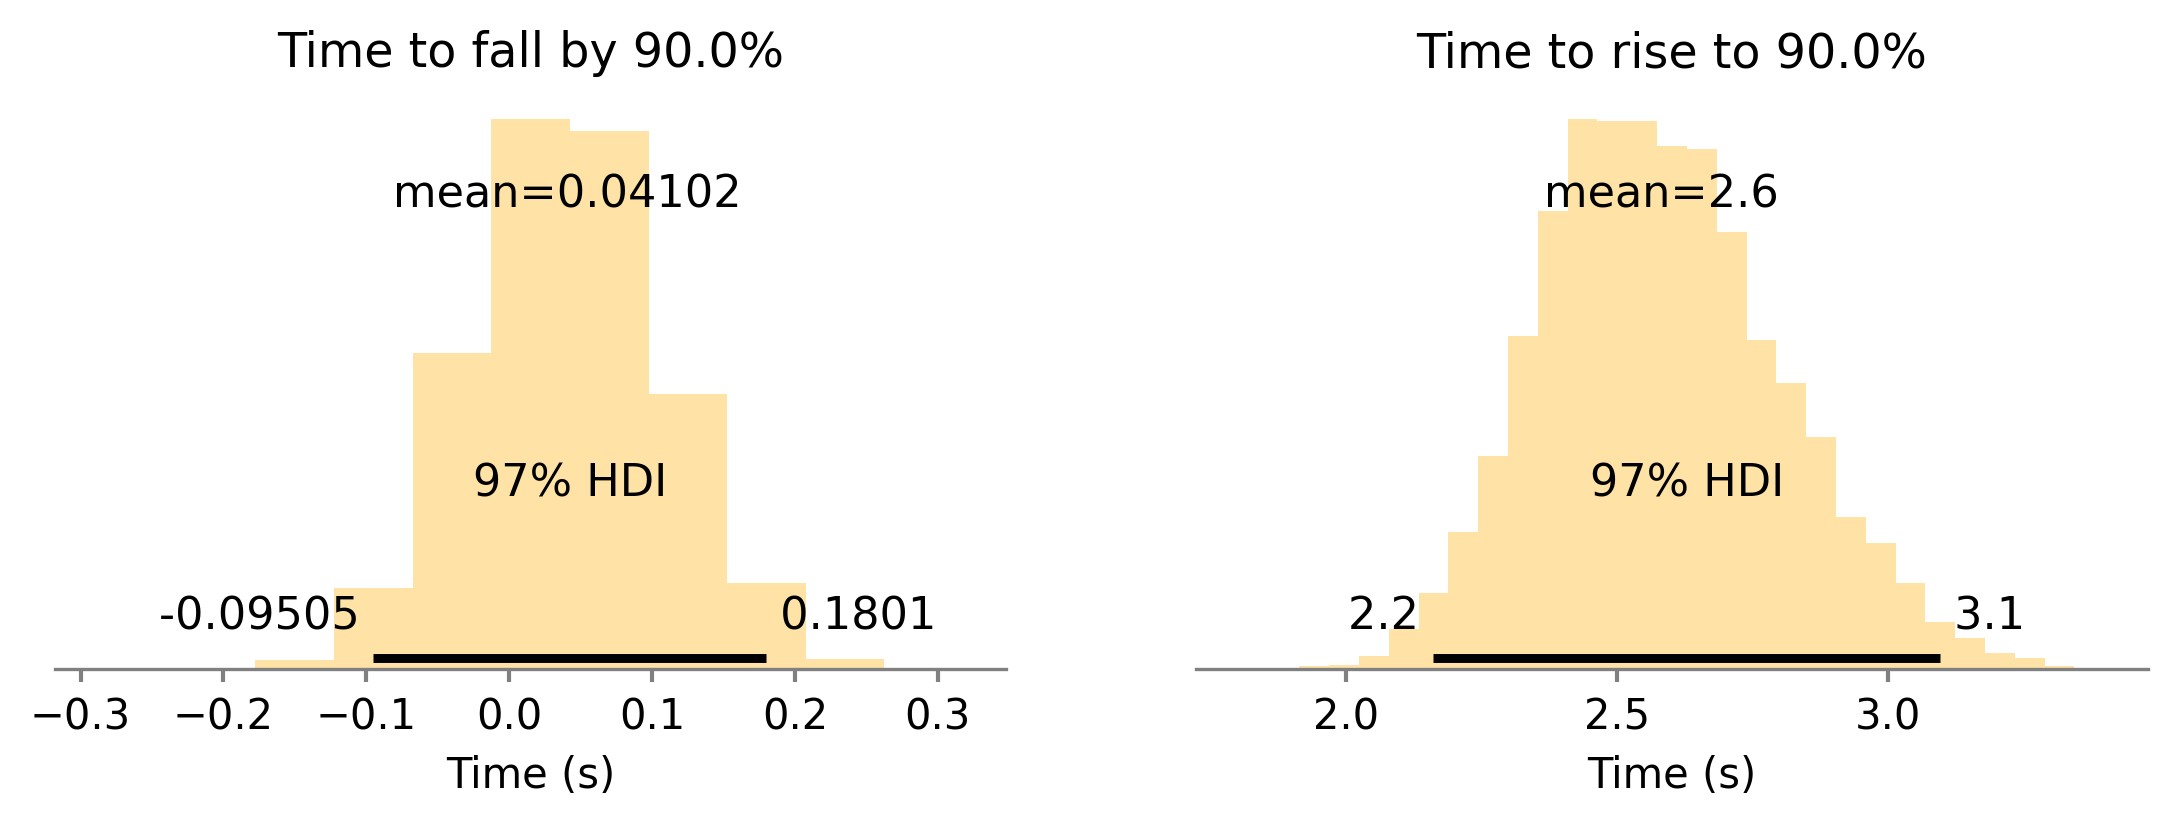

In [20]:
calculate_rate_percentages_of_peak_OFF(idata_predictions.predictions,X_test,cell_type='OFF')

In [ ]:
# Extract posterior lambda and summarize
lambda_preds = idata_predictions.predictions['rate']
lambda_mean = lambda_preds.mean(("chain","draw"))
# lambda_mean

count_preds = idata_predictions.predictions['count_pred_new']
count_pred_mean = count_preds.mean(("chain","draw"))

In [ ]:
preds_numpy = count_preds.to_numpy()
print(preds_numpy.shape)
preds_numpy = preds_numpy.T.reshape((2000,-1))
preds_numpy.shape

(4, 1000, 2000)


(2000, 4000)

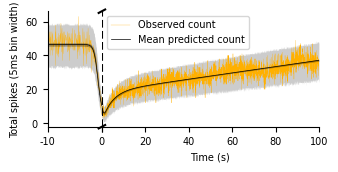

In [ ]:
plot_predictions_paper(counts,X_test,count_pred_mean,lambda_preds,lambda_mean,preds_numpy,
                       filename="21_switching_model_OFF_cells_linear_slope_aggregated",
                   basePath="./models/off_models/21_OFF_cells_linear_slope_aggregated",save=True)


## Store the model predictions for important quantities

In [ ]:
prediction_save_path: Path = Path("./models/off_models/21_OFF_cells_linear_slope_aggregated/OFF_model_exp_linear_mean_predictions")

data = {
    "counts":counts ,
    "X_test":X_test ,
    "count_pred_mean":count_pred_mean ,
    "lambda_preds":lambda_preds ,
    "lambda_mean":lambda_mean ,
    "preds_numpy":preds_numpy,
    "t_switch": idata.posterior['t_switch']

}

store_model_predictions(prediction_save_path,data)